# Integrating Learning and Planning

- Model-Based Reinforcement Learning
- Integrated Architectures
- Simulation-Based Search

- Last lecture: learn **policy** directly from experience
- Previous lectures: learn **value function** directly from experience
- This lecture: learn **model** directly from experience 
- and use **planning** to construct a value function or policy
- Integrate learning and planning into a single architecture

## Model-based and model-free RL

Model-Free RL
- No model
- Learn value function (and/or policy) from experience

<img src="imgs/image-109.png" width="400px">

Model-Based RL
- Learn a model from experience
- Plan value function (and/or policy) from model

<img src="imgs/image-110.png" width="400px">

## Model based RL

<img src="imgs/image-111.png" width="500px">

**Advantages**:
- Can eﬃciently learn model by supervised learning methods
- Can reason about model uncertainty

**Disadvantages**:
- First learn a model, then construct a value function
    
    ⇒ **two sources of approximation error**

### What is a Model?

A **model** $\mathcal{M}$ is a representation of an MDP $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R} \rangle$, parametrized by $\eta$.

We assume state space $\mathcal{S}$ and action space $\mathcal{A}$ are known.

A model $\mathcal{M} = \langle \mathcal{P}_\eta, \mathcal{R}_\eta \rangle$ approximates state transitions and rewards:

$$\mathcal{P}_\eta \approx \mathcal{P}, \quad \mathcal{R}_\eta \approx \mathcal{R}$$

$$S_{t+1} \sim \mathcal{P}_\eta(S_{t+1} \mid S_t, A_t)$$

$$R_{t+1} = \mathcal{R}_\eta(R_{t+1} \mid S_t, A_t)$$

We typically assume **conditional independence** between state transitions and rewards — knowing the current state and action is enough to predict each separately:

$$\mathbb{P}[S_{t+1}, R_{t+1} \mid S_t, A_t] = \mathbb{P}[S_{t+1} \mid S_t, A_t]\, \mathbb{P}[R_{t+1} \mid S_t, A_t]$$

**In plain terms:** instead of working with the true unknown environment, we learn a model $\mathcal{M}$ that approximates it. The model has two learned components: one that predicts *where you go* ($\mathcal{P}_\eta$) and one that predicts *what reward you get* ($\mathcal{R}_\eta$), and these two predictions are treated as independent of each other.

### Model Learning

**Goal:** estimate model $\mathcal{M}_\eta$ from experience $\{S_1, A_1, R_2, ..., S_T\}$.

This is a **supervised learning problem** — we treat each transition as a labeled training example:

$$S_1, A_1 \rightarrow R_2, S_2$$
$$S_2, A_2 \rightarrow R_3, S_3$$
$$\vdots$$
$$S_{T-1}, A_{T-1} \rightarrow R_T, S_T$$

Two sub-problems:

- Learning $s, a \rightarrow r$ is a **regression problem** — predict a scalar reward
- Learning $s, a \rightarrow s'$ is a **density estimation problem** — predict a distribution over next states

**Procedure:**
1. Pick a loss function (e.g. mean-squared error, KL divergence, ...)
2. Find parameters $\eta$ that minimise the empirical loss over collected transitions

**In plain terms:** we have a log of (state, action) → (reward, next state) tuples from real experience. We train a model on this data just like any supervised ML task — regression for rewards, density estimation for transitions — and tune $\eta$ to minimise prediction error.

### Examples of Models

- **Table Lookup Model** — stores the empirical average reward and transition counts for each $(s, a)$ pair in a table. Simple and exact, but only works for small, discrete state/action spaces.

- **Linear Expectation Model** — approximates transitions and rewards as a linear function of features of $(s, a)$. Fast and interpretable, but can only capture linear relationships.

- **Linear Gaussian Model** — assumes the next state $s'$ is Gaussian-distributed with a mean that is linear in $(s, a)$. Adds uncertainty estimates on top of the linear model; useful for continuous control.

- **Gaussian Process Model** — non-parametric Bayesian model that places a prior over functions. Automatically quantifies uncertainty and works well with little data, but scales poorly to high dimensions.

- **Deep Belief Network Model** — uses a deep neural network to model transitions and rewards. Can capture complex, non-linear dynamics; scales to high-dimensional inputs like images, but requires lots of data and compute.

- **...** — any supervised learning method can in principle be used as a model.

### Table Lookup Model

The model is an explicit MDP with estimated transitions $\hat{\mathcal{P}}$ and rewards $\hat{\mathcal{R}}$.

**Count visits** $N(s, a)$ to each state-action pair, then estimate by averaging:

$$\hat{\mathcal{P}}^a_{s,s'} = \frac{1}{N(s,a)} \sum_{t=1}^{T} \mathbf{1}(S_t, A_t, S_{t+1} = s, a, s')$$

$$\hat{\mathcal{R}}^a_s = \frac{1}{N(s,a)} \sum_{t=1}^{T} \mathbf{1}(S_t, A_t = s, a) R_t$$

**In plain terms:** $\hat{\mathcal{P}}$ is just the fraction of times action $a$ in state $s$ led to state $s'$. $\hat{\mathcal{R}}$ is just the average reward received when taking action $a$ in state $s$.

---

**Alternative — store raw tuples:**

- At each time-step $t$, record the experience tuple $\langle S_t, A_t, R_{t+1}, S_{t+1} \rangle$
- To sample from the model, randomly pick a stored tuple matching $\langle s, a, \cdot, \cdot \rangle$

**In plain terms:** instead of pre-computing averages, just keep a replay buffer of all past transitions and sample from it on demand. Equivalent in expectation, but lazier — no aggregation needed upfront.

<img src="imgs/image-112.png" width="500px"/>

### Planning with a Model

Given a learned model $\mathcal{M}_\eta = \langle \mathcal{P}_\eta, \mathcal{R}_\eta \rangle$, solve the MDP $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}_\eta, \mathcal{R}_\eta \rangle$ using any standard planning algorithm:

- **Value iteration** — repeatedly update value estimates for all states until convergence
- **Policy iteration** — alternate between evaluating a policy and improving it greedily
- **Tree search** — simulate future trajectories by rolling out the model and pick the best action
- **...**

**In plain terms:** once you have a model, you forget about the real environment and just plan inside the model. The model acts as a cheap simulator — you can query it as many times as you want without any real-world cost, then use any planning method to extract a good policy.

### Sample-Based Planning

A simple but powerful approach: use the model **only to generate samples**, then apply model-free RL to those samples.

**Sample experience from the model:**

$$S_{t+1} \sim \mathcal{P}_\eta(S_{t+1} \mid S_t, A_t)$$

$$R_{t+1} = \mathcal{R}_\eta(R_{t+1} \mid S_t, A_t)$$

**Then apply any model-free RL algorithm to the simulated data:**

- Monte-Carlo control
- Sarsa
- Q-learning

Sample-based planning methods are often **more efficient** than full planning.

**In plain terms:** instead of solving the full MDP analytically, just use the model as a simulator to cheaply generate fake experience, then run standard RL on that fake data as if it were real. The key insight is that you never need to solve the model explicitly — you just sample from it. This is efficient because you sidestep the cost of sweeping over the entire state space.

#### back to AB example
<img src="imgs/image-113.png" width="500px"/>

### Planning with an Inaccurate Model

Given an imperfect model $\langle \mathcal{P}_\eta, \mathcal{R}_\eta \rangle \neq \langle \mathcal{P}, \mathcal{R} \rangle$:

- Performance of model-based RL is **limited to the optimal policy for the approximate MDP** $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}_\eta, \mathcal{R}_\eta \rangle$
- Model-based RL is only as good as the estimated model — garbage in, garbage out
- An inaccurate model leads to a **suboptimal policy**

**Two solutions:**

- **Solution 1:** when the model is too wrong, fall back to **model-free RL** directly on real experience
- **Solution 2:** **reason explicitly about model uncertainty** — track how confident you are in the model and act cautiously in regions where it is unreliable

**In plain terms:** if your simulator is wrong, planning inside it will find a policy that is optimal in the fake world but potentially terrible in the real one. You either abandon the model when it fails, or build uncertainty awareness into the planning process so the agent knows when not to trust its own model.

##  Integrated Architectures


### Dyna-Q on FrozenLake

**Dyna-Q** is the simplest integrated architecture:
1. **Direct RL** — Q-learning update from real experience
2. **Model Learning** — Store observed transitions in a table-lookup model
3. **Planning** — Replay $n$ simulated steps from the learned model

Each real step generates $n$ additional learning updates "for free", accelerating convergence.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
def epsilon_greedy(Q, state, n_actions, epsilon):
    """Select action using epsilon-greedy policy."""
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])


def q_learning(env, n_episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    """Plain Q-learning (model-free baseline)."""
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    episode_rewards = []
    episode_steps = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        steps = 0

        while True:
            action = epsilon_greedy(Q, state, n_actions, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Q-learning update
            Q[state, action] += alpha * (
                reward
                + gamma * np.max(Q[next_state]) * (1 - terminated)
                - Q[state, action]
            )

            state = next_state
            total_reward += reward
            steps += 1
            if done:
                break

        episode_rewards.append(total_reward)
        episode_steps.append(steps)

    return Q, episode_rewards, episode_steps

In [3]:
def dyna_q(env, n_episodes=500, n_planning=10, alpha=0.1, gamma=0.99, epsilon=0.1):
    """
    Dyna-Q: Q-learning + table-lookup model learning + planning.

    For each real step:
      1. Q-learning update (direct RL)
      2. Update model with observed (s, a) -> (r, s')
      3. n_planning simulated Q-learning updates from model (planning)
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    # Table-lookup model: model[(s, a)] = (reward, next_state)
    model = {}
    # Track visited (state, action) pairs for sampling during planning
    visited_sa = []

    episode_rewards = []
    episode_steps = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        steps = 0

        while True:
            action = epsilon_greedy(Q, state, n_actions, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # --- (a) Direct RL: Q-learning update ---
            Q[state, action] += alpha * (
                reward
                + gamma * np.max(Q[next_state]) * (1 - terminated)
                - Q[state, action]
            )

            # --- (b) Model learning: store transition ---
            if (state, action) not in model:
                visited_sa.append((state, action))
            model[(state, action)] = (reward, next_state, terminated)

            # --- (c) Planning: n simulated Q-learning updates ---
            for _ in range(n_planning):
                idx = np.random.randint(len(visited_sa))
                s_sim, a_sim = visited_sa[idx]
                r_sim, s_next_sim, term_sim = model[(s_sim, a_sim)]
                Q[s_sim, a_sim] += alpha * (
                    r_sim
                    + gamma * np.max(Q[s_next_sim]) * (1 - term_sim)
                    - Q[s_sim, a_sim]
                )

            state = next_state
            total_reward += reward
            steps += 1
            if done:
                break

        episode_rewards.append(total_reward)
        episode_steps.append(steps)

    return Q, episode_rewards, episode_steps, model

### Training: Q-learning vs Dyna-Q

We compare pure Q-learning (no planning) against Dyna-Q with different numbers of planning steps $n \in \{5, 10, 50\}$.

Using **FrozenLake-v1** (non-slippery) — a 4×4 grid where the agent must reach the goal while avoiding holes. Deterministic transitions make the learned model accurate immediately.

In [4]:
n_episodes = 300
n_runs = 20  # average over multiple runs to reduce variance

env = gym.make("FrozenLake-v1", is_slippery=False)

configs = [
    ("Q-learning (n=0)", 0),
    ("Dyna-Q (n=5)", 5),
    ("Dyna-Q (n=10)", 10),
    ("Dyna-Q (n=50)", 50),
]

results = {}
for label, n_plan in configs:
    all_rewards = np.zeros((n_runs, n_episodes))
    for run in range(n_runs):
        if n_plan == 0:
            _, rewards, _ = q_learning(env, n_episodes=n_episodes)
        else:
            _, rewards, _, _ = dyna_q(env, n_episodes=n_episodes, n_planning=n_plan)
        all_rewards[run] = rewards
    results[label] = all_rewards
    # cumulative success rate at end
    final_success = all_rewards[:, -50:].mean()
    print(f"{label:20s} | final success rate (last 50 eps): {final_success:.2f}")

Q-learning (n=0)     | final success rate (last 50 eps): 0.00
Dyna-Q (n=5)         | final success rate (last 50 eps): 0.00
Dyna-Q (n=10)        | final success rate (last 50 eps): 0.00
Dyna-Q (n=50)        | final success rate (last 50 eps): 0.00


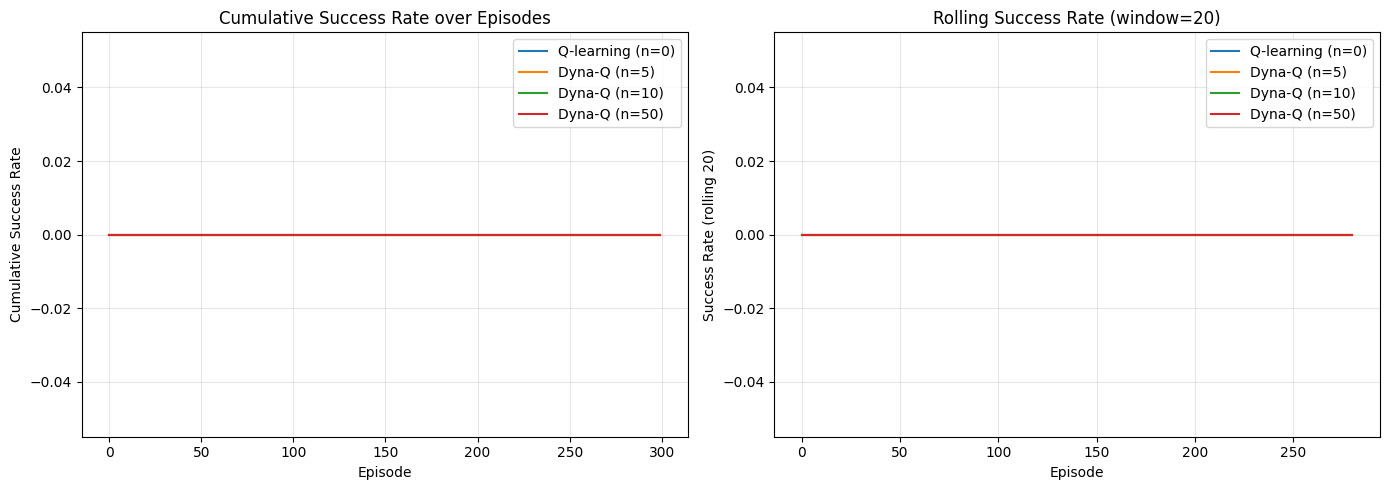

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

window = 20  # rolling window for smoothing
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# --- Left: cumulative success rate ---
ax = axes[0]
for (label, _), color in zip(configs, colors):
    mean_rewards = results[label].mean(axis=0)
    cum_success = np.cumsum(mean_rewards) / (np.arange(n_episodes) + 1)
    ax.plot(cum_success, label=label, color=color)
ax.set_xlabel("Episode")
ax.set_ylabel("Cumulative Success Rate")
ax.set_title("Cumulative Success Rate over Episodes")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: rolling success rate ---
ax = axes[1]
for (label, _), color in zip(configs, colors):
    mean_rewards = results[label].mean(axis=0)
    rolling = np.convolve(mean_rewards, np.ones(window) / window, mode="valid")
    ax.plot(rolling, label=label, color=color)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Success Rate (rolling {window})")
ax.set_title(f"Rolling Success Rate (window={window})")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Inspecting the Learned Model and Policy

The table-lookup model stores $(s, a) \to (r, s', \text{terminated})$ for every transition the agent has observed. Let's train a single Dyna-Q agent and visualize:
- The **learned policy** (greedy w.r.t. Q)
- The **learned model** (what transitions the agent remembers)

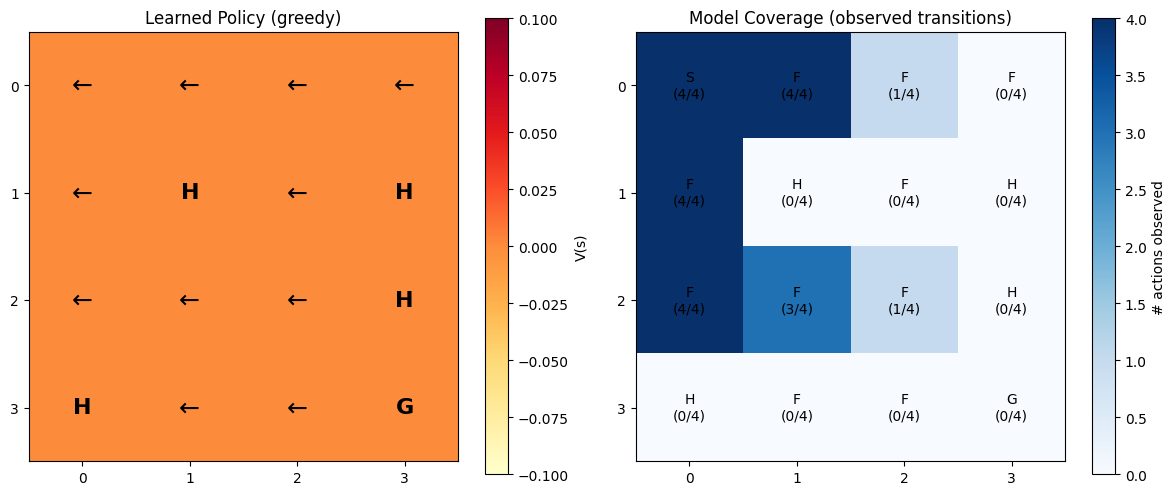


Sample model entries:
  Model(0, ←) → s'=0, r=0, done=False
  Model(0, ↓) → s'=4, r=0, done=False
  Model(0, →) → s'=1, r=0, done=False
  Model(0, ↑) → s'=0, r=0, done=False
  Model(1, ←) → s'=0, r=0, done=False
  Model(1, ↓) → s'=5, r=0, done=True
  Model(1, →) → s'=2, r=0, done=False
  Model(1, ↑) → s'=1, r=0, done=False
  Model(2, ←) → s'=1, r=0, done=False
  Model(4, ←) → s'=4, r=0, done=False


In [7]:
# Train a single Dyna-Q agent
env_vis = gym.make("FrozenLake-v1", is_slippery=False)
Q_dyna, _, _, learned_model = dyna_q(env_vis, n_episodes=300, n_planning=50)

# FrozenLake 4x4 layout
grid_size = 4
action_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
desc = env_vis.unwrapped.desc.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Learned policy ---
ax = axes[0]
V = np.max(Q_dyna, axis=1).reshape(grid_size, grid_size)
im = ax.imshow(V, cmap="YlOrRd", interpolation="nearest")
plt.colorbar(im, ax=ax, label="V(s)")

for s in range(grid_size * grid_size):
    r, c = divmod(s, grid_size)
    cell = desc[r, c]
    if cell in ("H", "G"):
        ax.text(c, r, cell, ha="center", va="center", fontsize=16, fontweight="bold")
    else:
        best_a = np.argmax(Q_dyna[s])
        ax.text(c, r, action_arrows[best_a], ha="center", va="center", fontsize=18)

ax.set_title("Learned Policy (greedy)")
ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))

# --- Right: Learned model coverage ---
ax = axes[1]
coverage = np.zeros((grid_size, grid_size))
for s, a in learned_model:
    r, c = divmod(s, grid_size)
    coverage[r, c] += 1  # count how many actions have been observed

im2 = ax.imshow(coverage, cmap="Blues", interpolation="nearest")
plt.colorbar(im2, ax=ax, label="# actions observed")

for s in range(grid_size * grid_size):
    r, c = divmod(s, grid_size)
    cell = desc[r, c]
    n_observed = sum(1 for a in range(4) if (s, a) in learned_model)
    ax.text(c, r, f"{cell}\n({n_observed}/4)", ha="center", va="center", fontsize=10)

ax.set_title("Model Coverage (observed transitions)")
ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))

plt.tight_layout()
plt.show()

print("\nSample model entries:")
for (s, a), (rew, ns, term) in sorted(learned_model.items())[:10]:
    print(f"  Model({s}, {action_arrows[a]}) → s'={ns}, r={rew}, done={term}")

### Watch the Agent Play

Run the trained Dyna-Q policy greedily on FrozenLake and animate the agent's path step by step.

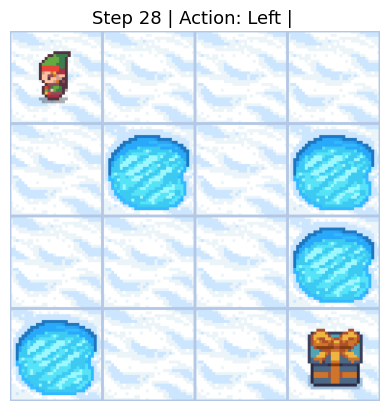

KeyboardInterrupt: 

In [11]:
from IPython.display import clear_output
import time

action_names = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}


def play_episode(Q, env_id="FrozenLake-v1", is_slippery=False, delay=0.5):
    """Play one episode using greedy policy from Q, rendering RGB frames."""
    env = gym.make(env_id, is_slippery=is_slippery, render_mode="rgb_array")
    state, _ = env.reset()

    clear_output(wait=True)
    plt.imshow(env.render())
    plt.axis("off")
    plt.title("Step 0 | Start", fontsize=13)
    plt.show()
    time.sleep(delay)

    for step in range(1, 51):
        action = np.argmax(Q[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        clear_output(wait=True)
        plt.imshow(env.render())
        plt.axis("off")
        status = (
            "GOAL!" if (terminated and reward > 0) else ("HOLE!" if terminated else "")
        )
        plt.title(
            f"Step {step} | Action: {action_names[action]} | {status}",
            fontsize=13,
            color="green"
            if status == "GOAL!"
            else ("red" if status == "HOLE!" else "black"),
        )
        plt.show()
        time.sleep(delay)

        if done:
            break
        state = next_state

    env.close()


play_episode(Q_dyna)